# 03-b — ROI Pre-processing Deep Dive

Step-by-step visual walkthrough of the **Region of Interest** detection algorithm
used before OCR. We crack open `ROIStep` and trace every intermediate result.

In [1]:
import sys

sys.path.insert(0, '..')

import cv2
import matplotlib.pyplot as plt
import numpy as np

from ocr_manga_title.preprocess.steps.roi import ROIStep

roi = ROIStep()
print(f'Step name : {roi.name}')
print(f'Available : {roi.is_available}')

Step name : roi
Available : True


## 1. Load a real manga screenshot

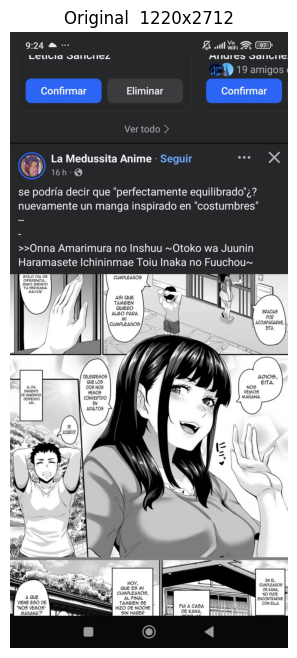

In [2]:
image_path = "/Users/rconsuegra/Pictures/images/Screenshot_2026-03-22-09-24-57-281_com.facebook.katana.jpg"
img_bgr = cv2.imread(image_path)
assert img_bgr is not None, f'Image not found: {image_path}'
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title(f'Original  {img_bgr.shape[1]}x{img_bgr.shape[0]}')
plt.axis('off')
plt.show()

## 2. Trace the contour-detection algorithm

The ROI step internally does:

1. Convert to grayscale
2. Gaussian blur (3x3)
3. Adaptive threshold (binary inverse)
4. Find external contours
5. Filter by `min_area`
6. Merge overlapping rects (IoU > `merge_overlap`)
7. Take the union of all merged rects
8. Pad and crop

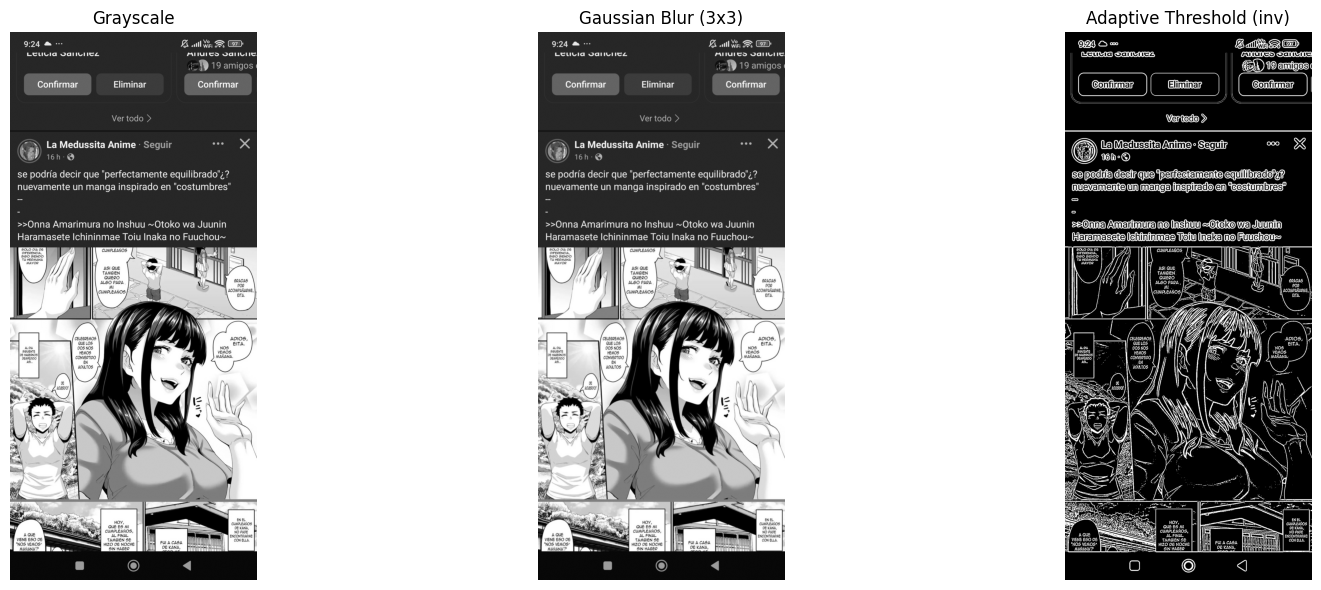

In [3]:
gray = img_bgr if img_bgr.ndim == 2 else cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
thresh = cv2.adaptiveThreshold(
    blurred, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, im, title in zip(
    axes,
    [gray, blurred, thresh],
    ['Grayscale', 'Gaussian Blur (3x3)', 'Adaptive Threshold (inv)'],
):
    ax.imshow(im, cmap='gray')
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Contours & bounding boxes

Total contours : 1665
After min_area=500 filter: 146 rects


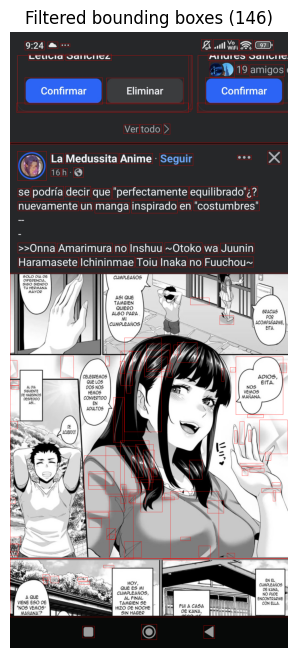

In [4]:
min_area = 500

contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
all_rects = [cv2.boundingRect(c) for c in contours]
filtered = [(x, y, w, h) for (x, y, w, h) in all_rects if w * h >= min_area]

print(f'Total contours : {len(contours)}')
print(f'After min_area={min_area} filter: {len(filtered)} rects')

vis = img_rgb.copy()
for x, y, w, h in filtered:
    cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), 1)

plt.figure(figsize=(8, 8))
plt.imshow(vis)
plt.title(f'Filtered bounding boxes ({len(filtered)})')
plt.axis('off')
plt.show()

## 4. Merge → union → final crop

In [5]:
config = {"method": "contour", "min_area": 500, "padding": 10, "merge_overlap": 0.3}

cropped, meta = roi.process(img_bgr, config)
print('Metadata:')
for k, v in meta.items():
    print(f'  {k}: {v}')

if meta['crop_performed']:
    bb = meta['bounding_box']
    vis2 = img_rgb.copy()
    cv2.rectangle(
        vis2,
        (bb['x'], bb['y']),
        (bb['x'] + bb['w'], bb['y'] + bb['h']),
        (0, 255, 0), 2,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(vis2)
    axes[0].set_title(f'ROI bounding box (green) — coverage {meta["coverage"]}')
    axes[0].axis('off')

    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB) if cropped.ndim == 3 else cropped
    axes[1].imshow(cropped_rgb, cmap='gray' if cropped.ndim == 2 else None)
    axes[1].set_title(f'Cropped  {cropped.shape[1]}x{cropped.shape[0]}')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f'Crop skipped — reason: {meta.get("reason", "unknown")}')

Metadata:
  method: contour
  regions_detected: 84
  regions_merged: 1
  crop_performed: False
  reason: coverage_too_large
  coverage: 0.974
Crop skipped — reason: coverage_too_large


## 5. Parameter sweep — `min_area`

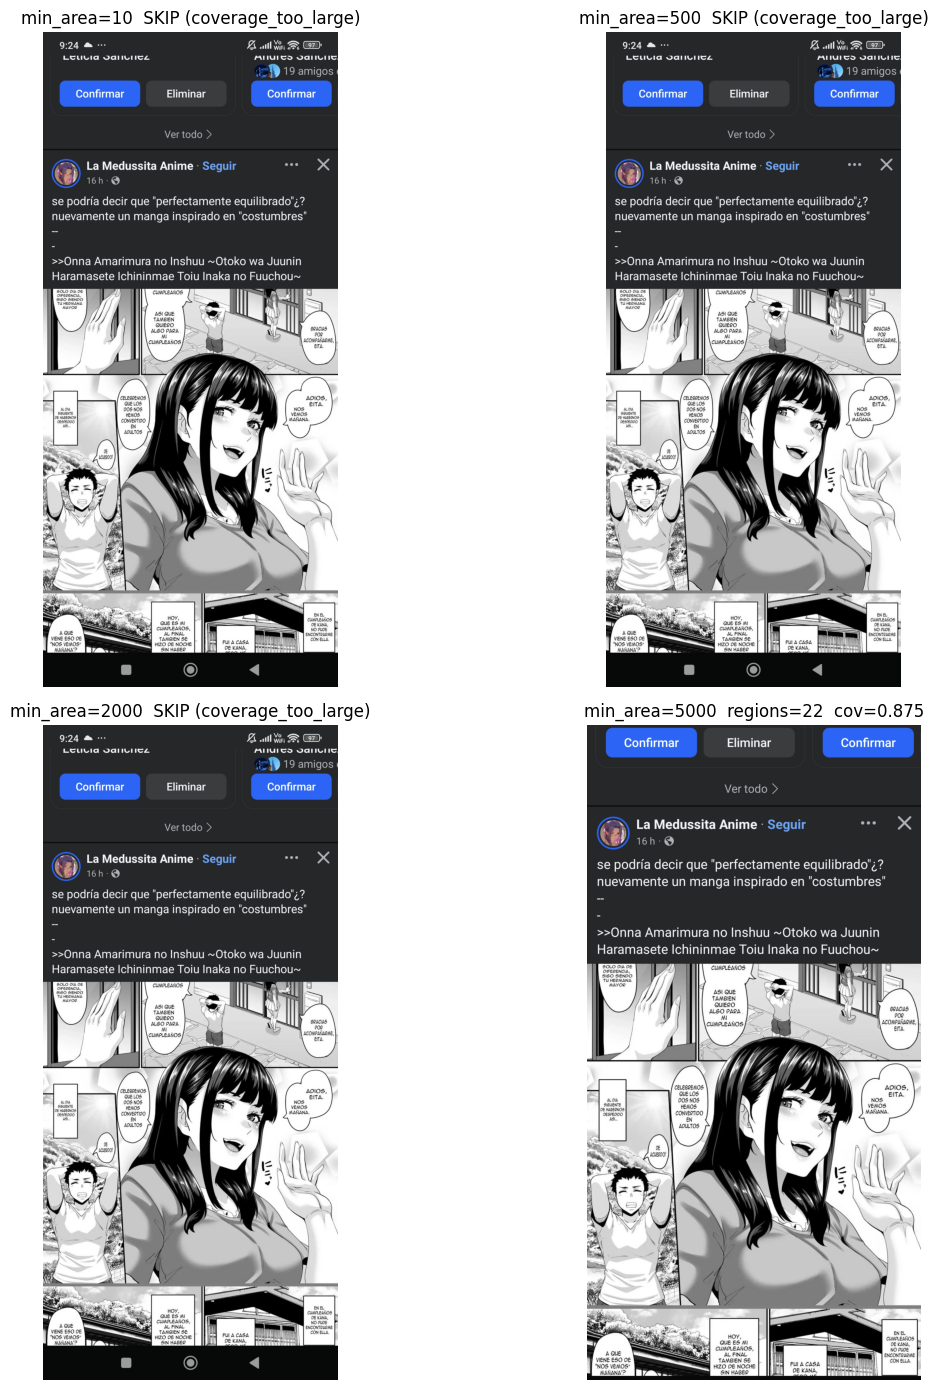

In [9]:
min_areas = [100, 500, 2000, 5000]
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.ravel()

for ax, ma in zip(axes, min_areas):
    _, m = roi.process(img_bgr, {**config, "min_area": ma})
    if m['crop_performed']:
        cropped_rgb = cv2.cvtColor(
            roi.process(img_bgr, {**config, "min_area": ma})[0],
            cv2.COLOR_BGR2RGB,
        )
        ax.imshow(cropped_rgb)
        ax.set_title(f'min_area={ma}  regions={m["regions_detected"]}  cov={m["coverage"]}')
    else:
        ax.imshow(img_rgb)
        ax.set_title(f'min_area={ma}  SKIP ({m.get("reason", "?")})')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Parameter sweep — `padding`

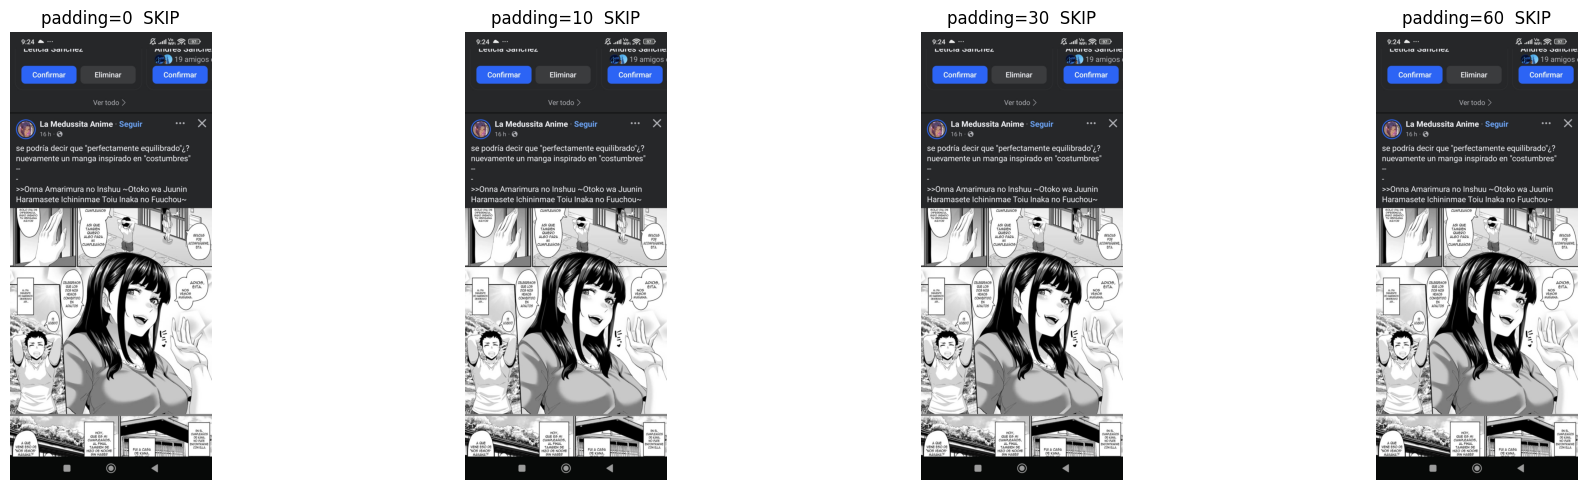

In [7]:
paddings = [0, 10, 30, 60]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, pad in zip(axes, paddings):
    cropped, m = roi.process(img_bgr, {**config, "padding": pad})
    if m['crop_performed']:
        cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
        ax.imshow(cropped_rgb)
        bb = m['bounding_box']
        ax.set_title(f'padding={pad}  → {bb["w"]}x{bb["h"]}')
    else:
        ax.imshow(img_rgb)
        ax.set_title(f'padding={pad}  SKIP')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Edge cases

In [8]:
cases = {
    'Tiny (<100px)': np.random.randint(0, 255, (80, 80, 3), dtype=np.uint8),
    'Blank': np.zeros((300, 300), dtype=np.uint8),
    'Full-white': np.full((300, 300), 255, dtype=np.uint8),
}

for label, test_img in cases.items():
    _, m = roi.process(test_img, config)
    print(f'{label:20s}  crop={m["crop_performed"]}  reason={m.get("reason", "-")}  regions={m.get("regions_detected", 0)}')

Tiny (<100px)         crop=False  reason=image_too_small  regions=0
Blank                 crop=False  reason=no_regions  regions=0
Full-white            crop=False  reason=no_regions  regions=0
